In [1]:
# -------------------------------
# Task 1 — Data Exploration
# -------------------------------

import pandas as pd

# load data
df = pd.read_csv("students.csv")

print("\n--- First 5 Rows ---")
print(df.head())


# shape and data types
print("\n--- Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)


# summary stats
print("\n--- Summary Statistics ---")
print(df.describe())


# pass / fail count
print("\n--- Pass / Fail Count ---")
print(df['passed'].value_counts())


# average subject scores (pass vs fail)
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\n--- Average Scores (Passed Students) ---")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n--- Average Scores (Failed Students) ---")
print(df[df['passed'] == 0][subject_cols].mean())


# highest overall average student
df['avg_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_score'].idxmax()]

print("\n--- Top Student ---")
print(top_student['name'], "-", round(top_student['avg_score'], 2))


--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Shape ---
(15, 9)

--- Data Types ---
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
            m

In [2]:
import pandas as pd

df = pd.read_csv("students.csv")

print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


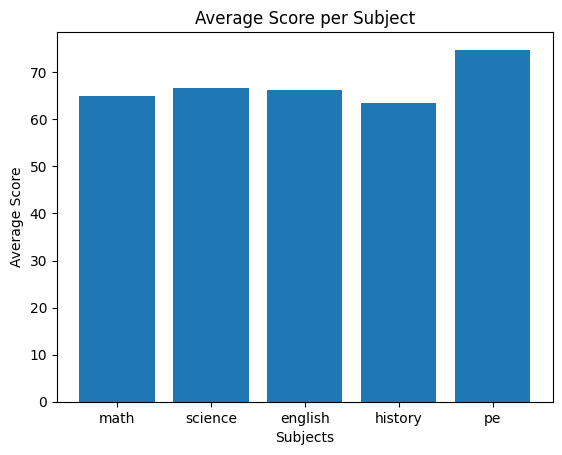

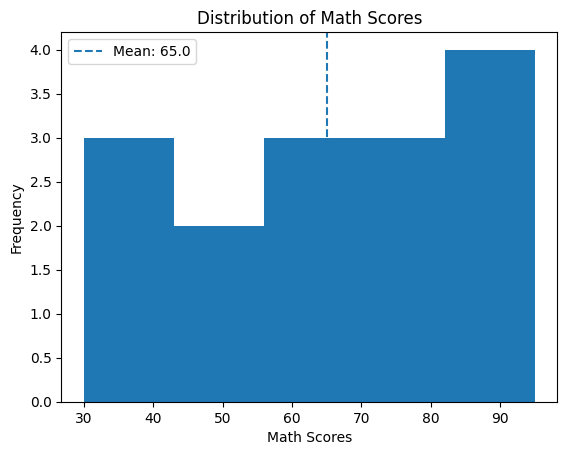

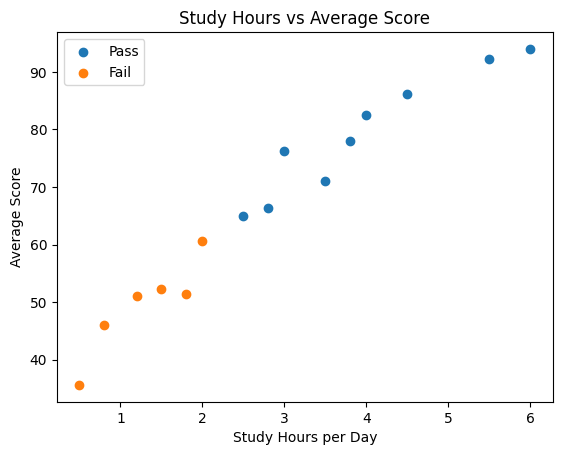

C:\Users\shiva\AppData\Local\Temp\ipykernel_6524\1740213617.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


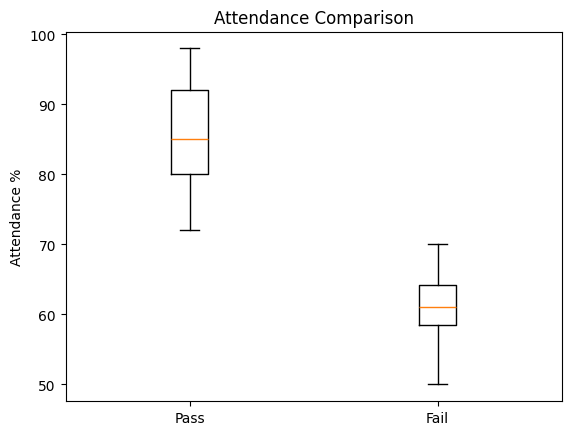

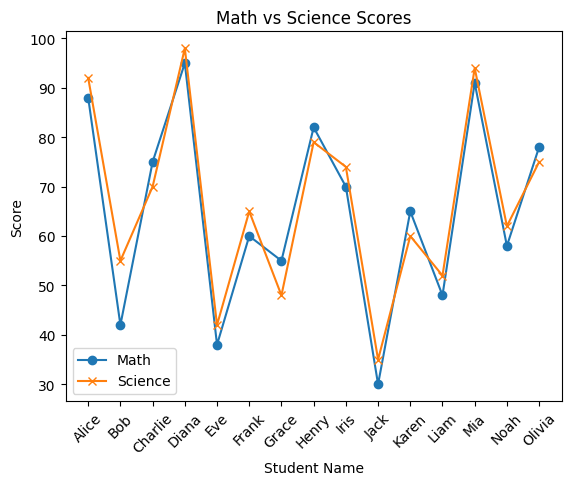

In [3]:
# -------------------------------
# Task 2 — Data Visualization
# -------------------------------

import matplotlib.pyplot as plt

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# 1. Bar Chart — Average score per subject
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()


# 2. Histogram — Math score distribution
plt.figure()
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean: {round(mean_math,2)}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()


# 3. Scatter Plot — Study hours vs avg_score
plt.figure()

passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]

plt.scatter(passed['study_hours_per_day'], passed['avg_score'], label="Pass")
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], label="Fail")

plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.title("Study Hours vs Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


# 4. Box Plot — Attendance comparison
pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])

plt.title("Attendance Comparison")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()


# 5. Line Plot — Math vs Science
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.xticks(rotation=45)
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.title("Math vs Science Scores")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

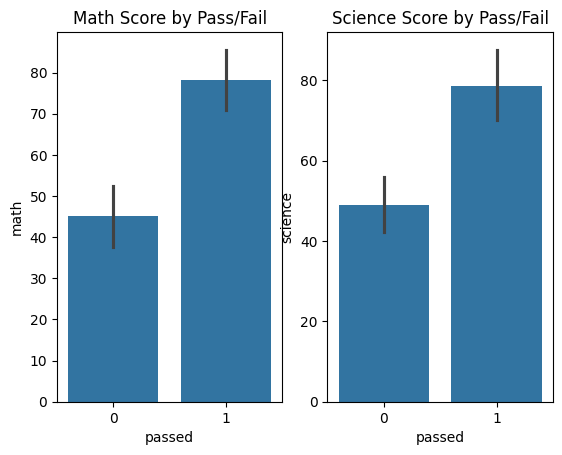

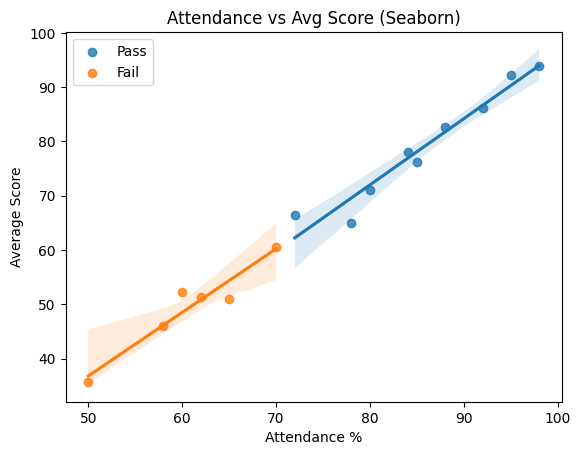

In [4]:
# -------------------------------
# Task 3 — Seaborn Visualization
# -------------------------------

import seaborn as sns
import matplotlib.pyplot as plt


# 1. Bar plot (math & science by pass/fail)

plt.figure()

plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math Score by Pass/Fail")

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science Score by Pass/Fail")

plt.savefig("plot6_seaborn_bar.png")
plt.show()


# 2. Scatter plot with regression lines

plt.figure()

# pass students
sns.regplot(data=df[df['passed']==1],
            x='attendance_pct',
            y='avg_score',
            label='Pass')

# fail students
sns.regplot(data=df[df['passed']==0],
            x='attendance_pct',
            y='avg_score',
            label='Fail')

plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.title("Attendance vs Avg Score (Seaborn)")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# -------------------------------
# Comment (important for marks)
# -------------------------------

# Seaborn was easier to use for grouped plots and statistical visuals like regression lines.
# It required less manual setup compared to Matplotlib.
# However, Matplotlib gives more control over customization if needed.


Training Accuracy: 1.0
Test Accuracy: 1.0

--- Predictions ---
Jack | Actual: 0 | Predicted: 0 | ✅ correct
Liam | Actual: 0 | Predicted: 0 | ✅ correct
Alice | Actual: 1 | Predicted: 1 | ✅ correct

--- Feature Importance ---
english : 0.813
attendance_pct : 0.522
study_hours_per_day : 0.484
pe : 0.475
math : 0.438
science : 0.323
history : 0.263


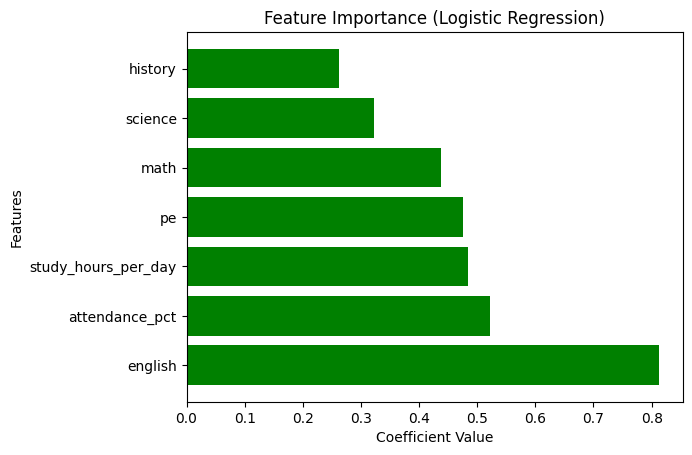


New Student Prediction: Pass
Probability: [[0.09203526 0.90796474]]


c:\Users\shiva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
# -------------------------------
# Task 4 — Machine Learning
# -------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt


# -------------------------------
# Step 1 — Prepare Data
# -------------------------------

feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -------------------------------
# Step 2 — Train Model
# -------------------------------

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("\nTraining Accuracy:", round(train_acc, 2))


# -------------------------------
# Step 3 — Evaluate Model
# -------------------------------

y_pred = model.predict(X_test_scaled)

test_acc = model.score(X_test_scaled, y_test)
print("Test Accuracy:", round(test_acc, 2))


print("\n--- Predictions ---")

names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    if actual == pred:
        result = "✅ correct"
    else:
        result = "❌ wrong"
    
    print(name, "| Actual:", actual, "| Predicted:", pred, "|", result)


# -------------------------------
# Step 4 — Feature Importance
# -------------------------------

coeffs = model.coef_[0]

feature_importance = list(zip(feature_cols, coeffs))

# sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n--- Feature Importance ---")
for f, c in feature_importance:
    print(f, ":", round(c, 3))


# plot
features = [f for f, c in feature_importance]
values = [c for f, c in feature_importance]

colors = []
for v in values:
    if v >= 0:
        colors.append("green")
    else:
        colors.append("red")

plt.figure()
plt.barh(features, values, color=colors)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.savefig("plot8_feature_importance.png")
plt.show()


# -------------------------------
# Step 5 — New Student Prediction
# -------------------------------

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)

if prediction == 1:
    result = "Pass"
else:
    result = "Fail"

print("\nNew Student Prediction:", result)
print("Probability:", prob)